In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import glob as glob

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter

# Aim: Compare model data (u,v) with ADCP 

# Load MITgcm data 

In [2]:
def load_data(run, output, var):

    # Change your path accordingly 
    path_in = "/Users/ramajem/Documents/mitgcm/archive/collated_out/{}/{}/".format(run,output)
    #path_drive = "/Volumes/WDElements/mitgcm/archive/collated_out/{}/{}/".format(run,output)

    fname_data = glob.glob(path_in + var + "*.nc")

    data = xr.open_mfdataset(fname_data, chunks={'X':8,'Y':16}).squeeze()
    data = data.sortby('T').drop_duplicates(dim='T')

    return (data)

In [3]:
run = 'nov2025_zug120'
output = '*' #or out1, out2,.. 
u_mit = load_data(run, output, "u").U
v_mit = load_data(run, output, "v").V

# Load ADCP data 
- Define your ADCP path accordingly 
- Ensure ADCP data is filtered/cleaned 

In [16]:
# path to mooring data
date = '20260114'
stn = 'LZC'
path_adcp = "/Users/ramajem/Documents/zug_observation/data/APhys/Mooring/L1/{}/{}/".format(date, stn)

#adcp serial number 
#adcp_sn = "*315*" 
adcp_sn = "*549*"

# start and end time (for slicing when ADCP is in water)
start_time = np.datetime64('2025-11-01T00:00:00.00')
end_time = np.datetime64('2026-01-14T00:00:00.00')

In [5]:
fname_adcp = glob.glob(path_adcp + adcp_sn)[0]

# Loading adcp data separately
adcp = xr.open_dataset(fname_adcp)
adcp = adcp.rename({"time":"T"})

# Slicing time (remove time when ADCP is out of water)
#adcp = adcp.sel(T=slice(start_time,end_time))

u_adcp = adcp.vel.sel(dir='E')
v_adcp = adcp.vel.sel(dir='N')


# Convert swiss coordinates (of ADCP location) to model coordinates 
- Add a function/code here to grab the coordinates from your metadata file

In [6]:
# location in swiss coordinates (of ADCP)
lon_pt = 680084
lat_pt = 218840

# point of origin of model in swiss grid 
XO_SG = 676648
YO_SG = 212416

xmit_pt  =  int(lon_pt) - XO_SG
ymit_pt = int(lat_pt) - YO_SG

print('xcoord on model:{}'.format(xmit_pt ))
print('ycoord on model:{}'.format(ymit_pt ))

xcoord on model:3436
ycoord on model:6424


## Quick plot to check location 

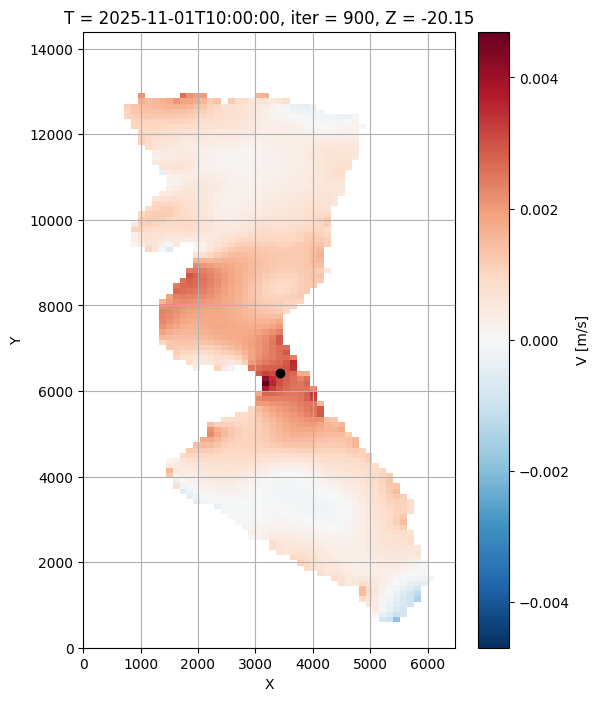

In [9]:
fig, ax = plt.subplots(1,figsize=(6, 8))

v_mit.sel(Z=-20,method="nearest").isel(T=10).plot()
plt.scatter(xmit_pt,ymit_pt,color="k")
plt.grid()

# Extract model data at mooring location 

In [8]:
u_mitxy = u_mit.sel(X=xmit_pt,Y=ymit_pt,method='nearest')
v_mitxy = v_mit.sel(X=xmit_pt,Y=ymit_pt,method='nearest')

# Plot MITgcm data 

Text(0.5, 1.0, 'LZ2')

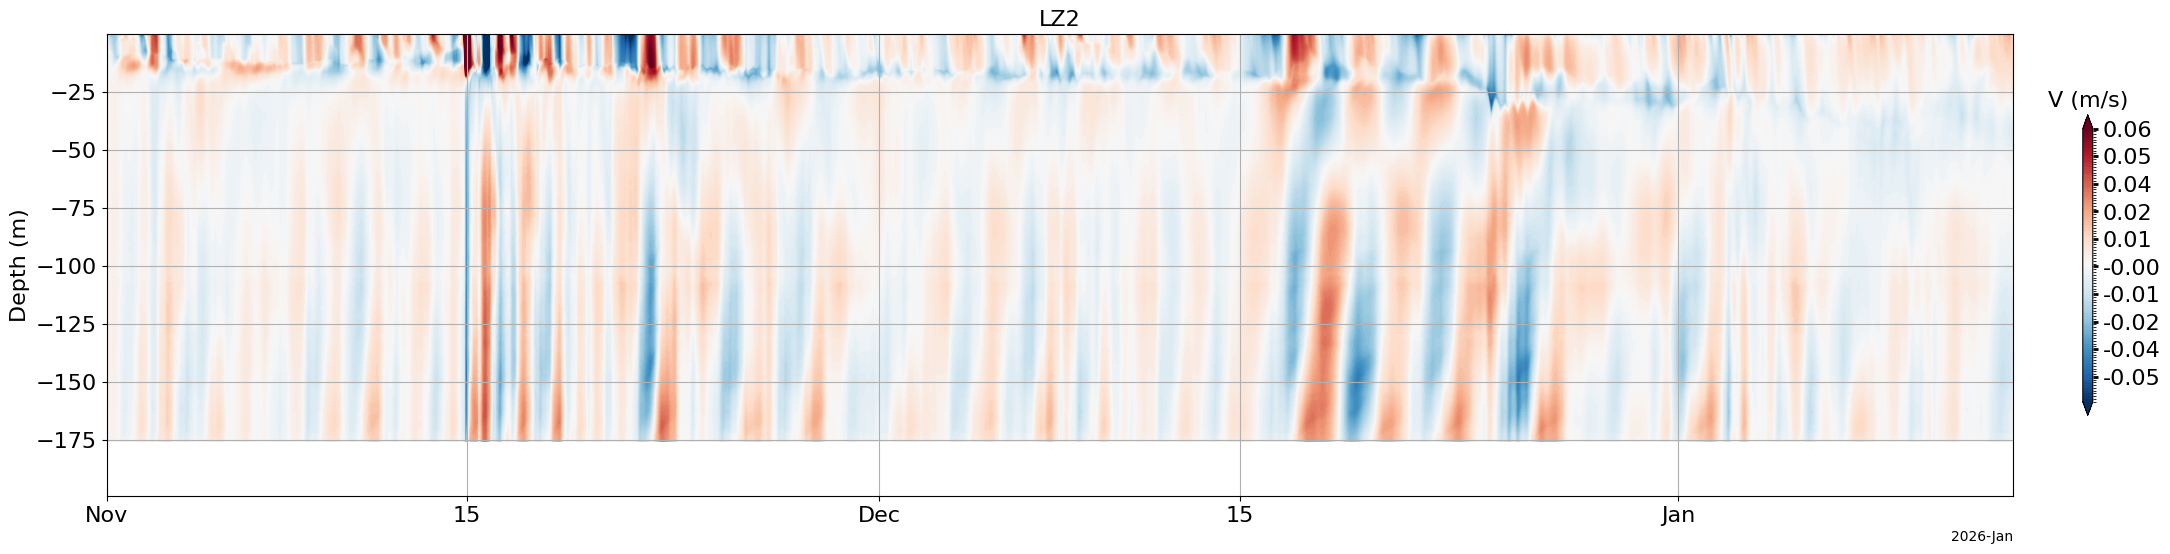

In [17]:
lsize = 16

vmin=-0.06 ; vmax=-vmin 
fig, ax = plt.subplots(1,figsize=(30, 6))
fig1 = v_mitxy.plot.contourf(y="Z",vmin=vmin, vmax=vmax, ax=ax,levels=100,cmap='RdBu_r',add_colorbar=False)

# Add horizontal colorbar
cbar = fig.colorbar(fig1, ax=ax, orientation='vertical', pad=0.03, shrink=0.65, aspect=30) #, fraction=0.4, shrink=0.5)

# Adjust the colorbar's tick parameters
cbar.ax.tick_params(labelsize=lsize, width=2)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.set_title('V (m/s)', fontsize=lsize)

ax.tick_params(axis='both', which='major', labelsize=lsize)  # Adjust parameters as needed


plt.xlim(start_time,end_time)
plt.ylabel('Depth (m)',fontsize=lsize)
plt.xlabel('',fontsize=lsize)
plt.grid()
plt.title('LZ2',fontsize=lsize)

# Plot ADCP data 

Text(0.5, 1.0, 'LZ2')

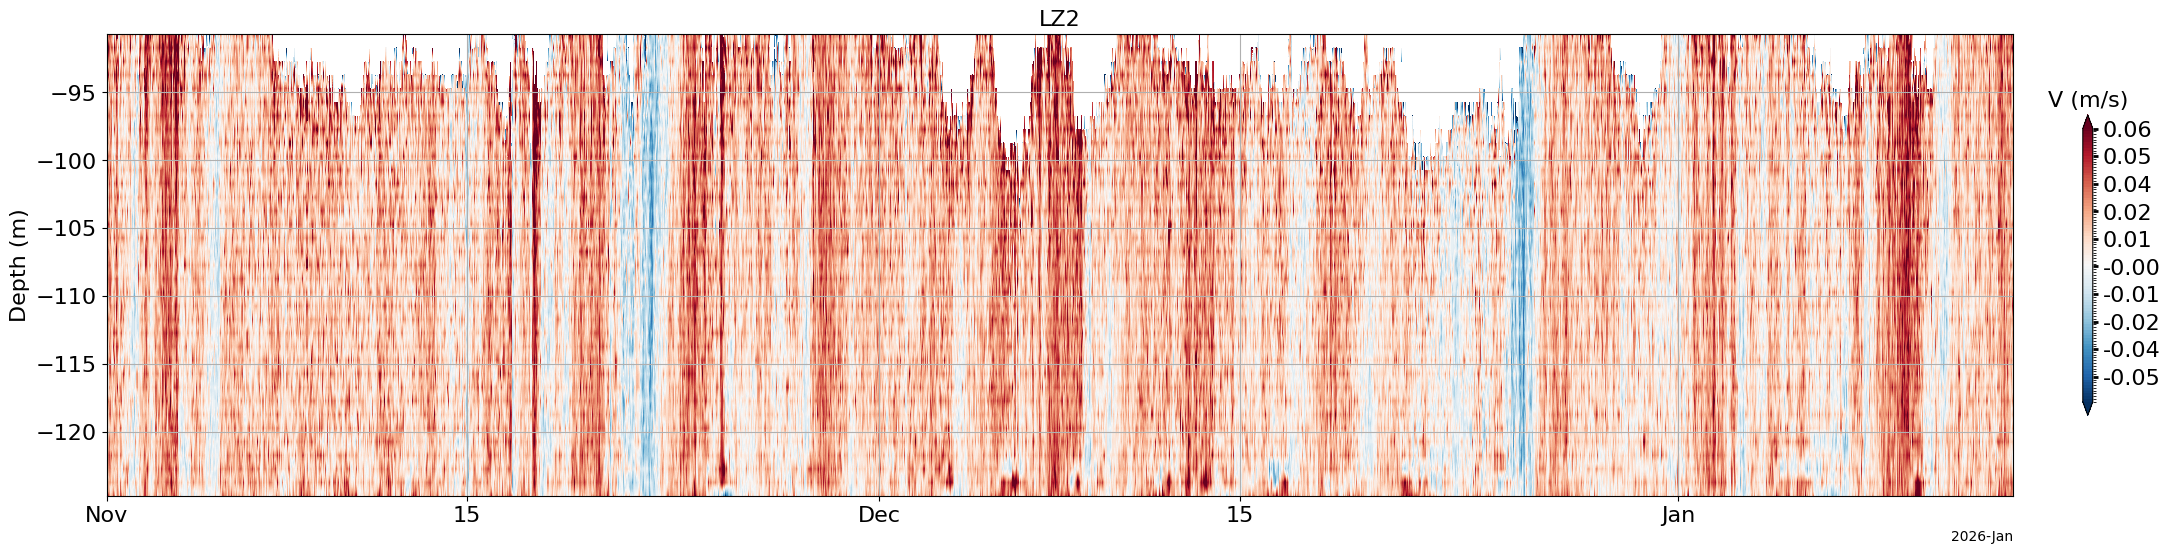

In [18]:
lsize = 16

vmin=-0.06 ; vmax=-vmin 
fig, ax = plt.subplots(1,figsize=(30, 6))
fig1 = v_adcp.plot.contourf(vmin=vmin, vmax=vmax, ax=ax,levels=100,cmap='RdBu_r',add_colorbar=False)

# Add horizontal colorbar
cbar = fig.colorbar(fig1, ax=ax, orientation='vertical', pad=0.03, shrink=0.65, aspect=30) #, fraction=0.4, shrink=0.5)

# Adjust the colorbar's tick parameters
cbar.ax.tick_params(labelsize=lsize, width=2)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.set_title('V (m/s)', fontsize=lsize)

ax.tick_params(axis='both', which='major', labelsize=lsize)  # Adjust parameters as needed


plt.xlim(start_time,end_time)
plt.ylabel('Depth (m)',fontsize=lsize)
plt.xlabel('',fontsize=lsize)
plt.grid()
plt.title('LZ2',fontsize=lsize)

# Plot velocity at specific depth 

Text(0.5, 1.0, 'Z:-105m')

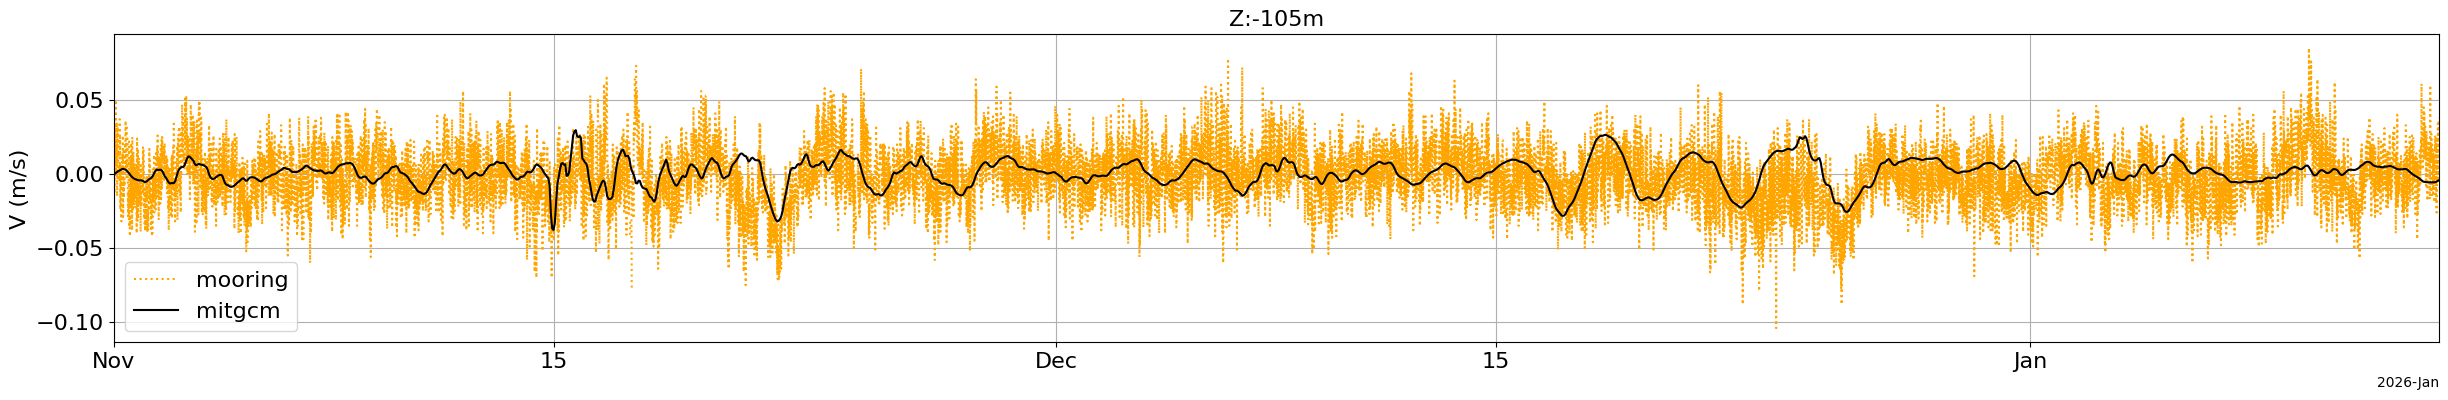

In [19]:
zz = -105

fig, ax = plt.subplots(1,figsize=(30, 4))
v_adcp.sel(Z=zz, method='nearest').plot(linestyle=':',color='orange', label='mooring')
v_mitxy.sel(Z=zz, method='nearest').plot(color='k', linewidth=1.5, label='mitgcm')

plt.xlim(pd.to_datetime(start_time),pd.to_datetime(end_time))
plt.grid()

ax.tick_params(axis='both', which='major', labelsize=lsize) 
plt.legend(fontsize=lsize)
plt.xlabel('')
plt.ylabel('V (m/s)',fontsize=lsize)
plt.title('Z:{}m'.format(zz), fontsize=lsize)


Text(0.5, 1.0, 'Z:-105m')

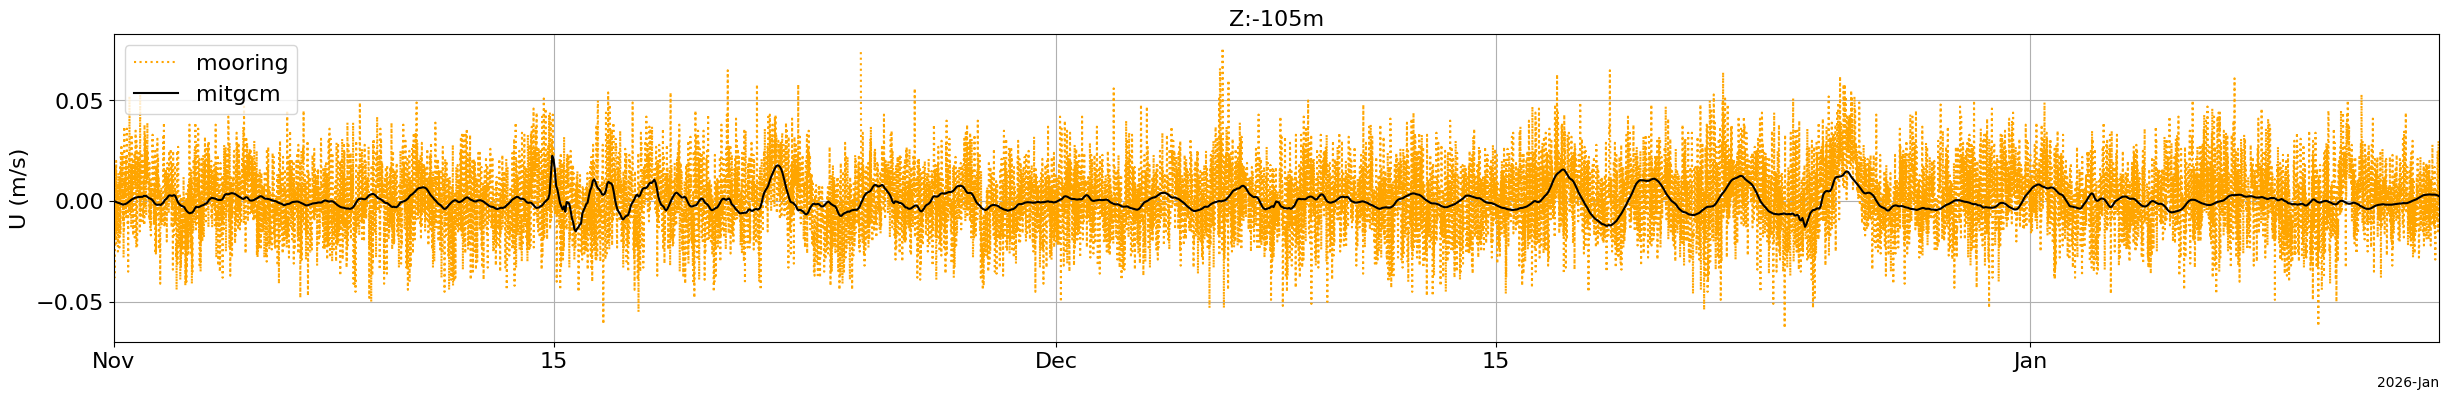

In [21]:
zz = -105

fig, ax = plt.subplots(1,figsize=(30, 4))
u_adcp.sel(Z=zz, method='nearest').plot(linestyle=':',color='orange', label='mooring')
u_mitxy.sel(Z=zz, method='nearest').plot(color='k', linewidth=1.5, label='mitgcm')

plt.xlim(pd.to_datetime(start_time),pd.to_datetime(end_time))
plt.grid()

ax.tick_params(axis='both', which='major', labelsize=lsize) 
plt.legend(fontsize=lsize)
plt.xlabel('')
plt.ylabel('U (m/s)',fontsize=lsize)
plt.title('Z:{}m'.format(zz), fontsize=lsize)